In this notebook, we enter the modeling phase of our predictive maintenance project. We will experiment with different models, perform hyperparameter tuning, and finally evaluate model performance on the NASA test set (`test_FD001.txt` and `RUL_FD001.txt`).

In [33]:
# Standard library
import os

# Third-party
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.base import clone
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Loading Features

In [2]:
# Load the features dataframe saved in notebook 2
df = pd.read_parquet('../data/processed/fd001_features.parquet.parquet')

In [77]:
df.columns

Index(['engine_number', 'time_cycle', 'setting_1', 'setting_2', 'sensor_2',
       'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_17', 'sensor_20', 'sensor_21', 'RUL', 'sensor_2_roll_mean_17',
       'sensor_3_roll_mean_17', 'sensor_4_roll_mean_17',
       'sensor_6_roll_mean_17', 'sensor_7_roll_mean_17',
       'sensor_8_roll_mean_17', 'sensor_9_roll_mean_17',
       'sensor_11_roll_mean_17', 'sensor_12_roll_mean_17',
       'sensor_13_roll_mean_17', 'sensor_14_roll_mean_17',
       'sensor_15_roll_mean_17', 'sensor_17_roll_mean_17',
       'sensor_20_roll_mean_17', 'sensor_21_roll_mean_17',
       'sensor_2_roll_std_10', 'sensor_3_roll_std_10', 'sensor_4_roll_std_10',
       'sensor_6_roll_std_10', 'sensor_7_roll_std_10', 'sensor_8_roll_std_10',
       'sensor_9_roll_std_10', 'sensor_11_roll_std_10',
       'sensor_12_roll_std_10', 'sensor_13_roll_std_10',
       'sensor_14

# Train/Validation Split

We perform an engine-based train/validation split to avoid data leakage. Since each engine represents an independent time series, splitting at row level would leak temporal and engine-specific patterns.

Instead, we split by engine IDs so that all cycles of a given engine are contained in either the training or validation set.

We use a 70/30 split (instead of 80/20) to obtain a slightly larger validation set, which leads to more stable evaluation metrics and a more reliable estimate of generalization across different degradation trajectories.

The exact ratio is not critical; the key principle is strict separation at engine level.

After the split, we remove `engine_number` and `time_cycle` from the feature set, as they are only required for splitting and time-based processing, not for model training.

In [3]:
# Get all engines
engines = df["engine_number"].unique()
engines

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [4]:
# Engine-level split
train_engines, val_engines = train_test_split(
    engines,
    test_size=0.3,
    random_state=42
)

In [5]:
# Filter data by engines
train_df = df[df["engine_number"].isin(train_engines)].copy()
val_df = df[df["engine_number"].isin(val_engines)].copy()

In [6]:
train_df["engine_number"].unique()

array([  2,   3,   4,   6,   7,   8,   9,  12,  14,  15,  17,  18,  20,
        21,  22,  24,  25,  26,  28,  29,  30,  33,  35,  36,  37,  38,
        39,  42,  44,  47,  48,  49,  50,  51,  52,  53,  55,  57,  58,
        59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  72,  75,
        76,  79,  80,  82,  83,  85,  86,  87,  88,  90,  92,  93,  94,
        95,  96,  98,  99, 100])

# Defining X and y

In this step, we separate the dataset into features (X) and the target variable (y). This distinction is required to prepare the data for model training, where X represents the input variables and y corresponds to the Remaining Useful Life (RUL).

Additionally, we remove the `engine_number` column from the feature set, as it is only an identifier and does not contain predictive information.

The `time_cycle` column is initially retained, as it may contain meaningful information about the operating duration of each engine and can serve as a relevant predictor for degradation modeling. Its influence will be evaluated during model training and feature importance analysis. In a second experiment, we will also test a variant where `time_cycle` is removed to assess its impact on model performance.

In [6]:
X_train = train_df.drop(["RUL", "engine_number"], axis=1)

In [7]:
y_train = train_df["RUL"]

In [8]:
X_val = val_df.drop(["RUL", "engine_number"], axis=1)

In [9]:
y_val = val_df["RUL"]

# Baseline Model

We start with a simple baseline model to serve as a reference for comparison. We train a basic linear regression model (without regularization) on the training set and evaluate its performance on the validation set.

We apply a clipping threshold to the target variable (RUL) prior to model training.

- **The problem:** In the early phase of an engine’s lifecycle, the system operates under stable conditions and sensor readings show little to no degradation. However, the Remaining Useful Life (RUL) decreases linearly from the beginning. This creates a mismatch between a changing target and largely stationary input features, which can lead the model to learn noise instead of meaningful degradation patterns.

- **The solution:** To address this, we cap the maximum RUL at a fixed threshold (e.g., 125 cycles). This flattens the target in the early lifecycle phase, ensuring that the model does not attempt to learn artificial degradation signals during periods of healthy operation.

- **The benefit:** This transformation improves learning stability by reducing sensitivity to non-informative early cycles. As a result, the model focuses more strongly on actual degradation-related behavior, leading to more robust and reliable error metrics during training.

- **Validation strategy:** To ensure a fair and consistent evaluation during model selection and hyperparameter tuning, validation performance is strictly measured against the clipped validation target (`y_val_clipped`). This ensures that training and evaluation are aligned in terms of target distribution and avoids misleading error signals in the early-life regime.

- **Production and testing outlook:** Final evaluation for production readiness is performed on the original, unclipped test set (`y_test`). Since the real-world test targets retain the full RUL range (including high values in the early lifecycle phase), a distribution mismatch is introduced in this region. During early cycles, the model will predict the clipped maximum RUL while the true values are higher, which can lead to inflated error metrics such as RMSE. However, this does not necessarily reflect reduced predictive quality in the degradation-critical phase close to failure, which remains the primary objective of the model.

We standardize the features for the baseline model. This is done for several reasons:

1. **More stable coefficients**  
   Standardization makes the intercept more interpretable and ensures that model weights become comparable across features.

2. **Improved numerical stability**  
   This is especially important in the presence of many correlated features, as it helps prevent feature dominance caused by differing value scales.

3. **Better interpretability**  
   After scaling, the importance of features becomes more comparable, allowing a clearer understanding of which variables contribute most to the prediction.

Furthermore, we train the baseline model twice: once including the `time_cycle` feature and once without it. This allows us to evaluate the impact of `time_cycle` on both model performance and learned parameters.

In [91]:
scaler = StandardScaler()

In [92]:
X_train_standardized = scaler.fit_transform(X_train)

In [93]:
X_val_standardized = scaler.transform(X_val)

In [94]:
baseline_model = LinearRegression()

In [95]:
baseline_model.fit(X_train_standardized, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](78,)","[-9.66,-0.28, 0.04,..., 2.27,-0.06, 2.04]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,90.93
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,78
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,78
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](78,)","[561. ,303.16,172.08,..., 11.66, 9.92, 5.01]"


In [96]:
joblib.dump(baseline_model, '../models/baseline_model_lin_reg.pkl')

['../models/baseline_model_lin_reg.pkl']

In [97]:
baseline_model = joblib.load('../models/baseline_model_lin_reg.pkl')

In [112]:
# Print the optimal weight (slope) and bias (intercept)
print("Coefficients (Slope):", baseline_model.coef_)
print("Intercept (Bias):", baseline_model.intercept_)

# Predict and score using test data
y_pred = baseline_model.predict(X_val_standardized)
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("R-squared Score:", r2_score(y_val, y_pred))

Coefficients (Slope): [-9.66399795e+00 -2.78670142e-01  3.70028789e-02  6.07464896e-03
 -4.28393260e-02  6.12049653e-02  2.58206101e-02  1.94187202e-01
  1.92190283e-01  3.17567584e-01 -5.55255134e-01 -4.20088490e-02
  1.59984963e-01  1.18364120e-01  3.94021012e-02 -1.89279868e-01
  4.64056675e-02  7.40660903e-02 -7.66539808e+00 -4.41405341e-02
 -4.99341367e+00  8.09830668e-01  6.91110265e+00  8.44799466e+00
  1.81295832e+01 -9.81236663e+00 -3.75356560e+00  1.29125079e+01
 -1.38438232e+01 -7.13850861e+00 -4.33947733e+00  3.21597372e+00
  4.13139916e+00  3.99567758e-02 -5.84570037e-01  7.48083554e-02
 -3.87265816e-01 -1.42576160e-01 -8.25310590e-01 -1.36010593e+00
  2.33674507e-01 -2.53737385e-01  6.86515992e-01 -2.66472632e-02
 -6.47495485e-01 -3.06144874e-01  1.25684235e-01  7.85014096e-01
  8.62865510e-02 -2.24396972e+00 -1.16121439e-01 -1.36802537e+00
 -6.18548890e-02 -2.88180466e+00  7.73323309e-02 -3.26977164e-01
  2.80364583e-02  2.95080108e+00  2.22787970e-01 -2.95665756e+00
  3

An R² score of approximately 0.80 is achieved, meaning that around 80% of the variance in the Remaining Useful Life (RUL) is explained by the linear regression baseline model.

For the FD001 dataset, which contains noisy and highly dynamic sensor signals, this represents a strong performance for a linear baseline model. It indicates that the engineered feature set already captures substantial predictive structure related to engine degradation.

The root mean squared error of approximately 22 is considered a strong result in this context, given that RUL values span a broad range (from 0 up to 200+ cycles). The metric is sensitive to larger deviations due to the squared error component, which amplifies occasional high prediction errors.

The learned coefficients show varying influence strengths across features. Negative coefficients indicate that increasing feature values are associated with a decrease in predicted RUL, which is consistent with degradation behavior. Positive coefficients indicate the opposite effect.

The wide range of coefficient magnitudes suggests strong feature correlation and redundancy within the engineered feature set, particularly due to rolling statistics and slope-based features. As a result, the linear model distributes weights unevenly across correlated inputs, and individual coefficients should not be interpreted in isolation but only in the context of the full feature space.

The intercept (~90.93) represents the baseline prediction of the model when all standardized features are equal to zero, i.e., when the engine is in an average operating state. In practical terms, this corresponds to an estimated remaining useful life of roughly 91 cycles under typical operating conditions in the dataset.

All evaluation metrics are computed on the clipped target variable (`y_clipped`). This clipped formulation is used consistently across all subsequent model comparisons to ensure a stable and comparable evaluation framework, while still preserving relative performance differences between models.

Overall, this result indicates that the model captures a meaningful and robust relationship between the engineered sensor features and the target variable, despite the inherent noise and complexity of the FD001 dataset.

In the following, we train a second variant of the baseline model without the `time_cycle` feature. We then briefly evaluate its performance and compare it to the original baseline model to assess the impact of `time_cycle` on predictive performance and learned parameters.

In [99]:
X_train_without_time_cycle = X_train.drop("time_cycle", axis=1)
X_val_without_time_cycle = X_val.drop("time_cycle", axis=1)

In [100]:
scaler_2 = StandardScaler()

In [101]:
X_train_without_time_cycle_standardized = scaler_2.fit_transform(X_train_without_time_cycle)

In [102]:
X_val_without_time_cycle_standardized = scaler_2.transform(X_val_without_time_cycle)

In [103]:
baseline_model_without_time_cycle = LinearRegression()

In [104]:
baseline_model_without_time_cycle.fit(X_train_without_time_cycle_standardized, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](77,)","[-0.2 ,-0.19, 0.03,..., 2.41,-0.08, 1.99]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,90.93
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,77
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,77
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](77,)","[555.24,302.65,172.07,..., 11.66, 9.92, 5.01]"


In [105]:
joblib.dump(baseline_model_without_time_cycle, '../models/baseline_model_without_time_cycle_lin_reg.pkl')

['../models/baseline_model_without_time_cycle_lin_reg.pkl']

In [106]:
baseline_model_without_time_cycle = joblib.load('../models/baseline_model_without_time_cycle_lin_reg.pkl')

In [114]:
# Print the optimal weight (slope) and bias (intercept)
print("Coefficients (Slope):", baseline_model_without_time_cycle.coef_)
print("Intercept (Bias):", baseline_model_without_time_cycle.intercept_)

# Predict and score using test data
y_pred = baseline_model_without_time_cycle.predict(X_val_without_time_cycle_standardized)
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_val, y_pred)))
print("R-squared Score:", r2_score(y_val, y_pred))

Coefficients (Slope): [-1.99756762e-01 -1.89964002e-01  3.09638096e-02  4.58904687e-03
  1.68941892e-01  5.42569792e-02  1.81533849e-01  1.86769755e-01
  1.70860247e-01 -5.47117751e-01 -1.20809362e-01  2.17886766e-01
  2.44993656e-01  7.69136400e-02 -2.25227029e-01  3.00538896e-03
  1.01450087e-01 -6.78074099e+00 -1.43974196e+00 -7.95647150e+00
  6.49817816e-01  7.53662113e+00  1.21634141e+01  1.26440190e+01
 -1.12686953e+01 -1.29597765e+00  1.51280595e+01 -1.10867735e+01
 -5.10629293e+00 -5.79971150e+00  5.98796100e+00  5.76309217e+00
 -3.51865526e-01 -6.22043504e-01 -1.22928719e-01 -6.50260285e-01
  7.61275845e-02 -8.84147197e-01 -4.81769863e-01  3.11058077e-01
 -4.84115344e-01  5.14163852e-01  5.89475134e-01 -5.57027324e-01
 -3.67286714e-01  2.41830039e-02  9.01718116e-01  1.22350954e-01
 -2.32766228e+00 -1.50227374e-01 -1.41513026e+00 -5.69808875e-02
 -3.05263738e+00  7.90894497e-02 -4.54085693e-01  1.73232081e-02
  3.13173644e+00  2.38249969e-01 -3.05755340e+00  3.15980542e-02
 -1

We observe that the model without the `time_cycle` feature performs slightly worse, achieving an R² score of approximately 0.77 and a root mean squared error of abou 24.

This indicates that the `time_cycle` feature contributes meaningfully to explaining variance in the target variable, as it encodes explicit temporal degradation information. However, the performance drop compared to the full model remains moderate, suggesting that a large portion of the predictive signal is already captured by the engineered sensor-based features.

The learned coefficients show a similar pattern to the previous model, with both positive and negative values indicating mixed feature contributions. The magnitude distribution again reflects strong correlations among engineered rolling and slope-based features, leading to shared or redistributed importance across related inputs.

Overall, while the removal of `time_cycle` reduces model performance, the linear baseline remains relatively strong, confirming that the feature engineering process already extracts substantial degradation-related structure from the raw sensor data.

# XGBoost Regression Model

After establishing a linear baseline, we now move to a significantly more powerful model architecture: Extreme Gradient Boosting (XGBoost).

Unlike linear regression, XGBoost is capable of learning complex non-linear relationships, feature interactions, and degradation dynamics directly from the engineered sensor features. This makes it particularly well-suited for predictive maintenance tasks such as Remaining Useful Life (RUL) estimation on the NASA FD001 dataset.

Mathematically, XGBoost operates as an ensemble of sequential decision trees. Each new tree is trained to minimize the residual errors of the previous trees by fitting the negative gradient of the loss function. In this way, the model iteratively improves its predictions by focusing on observations that were previously predicted poorly.

The final prediction is therefore constructed as the weighted sum of many weak decision trees, allowing the model to approximate highly complex non-linear functions while maintaining strong predictive performance and robustness.

In the following, we train and evaluate an XGBoost regressor and compare its performance against the previously established baseline models.

For our XGBoost regressor, unlike the linear baseline models, several hyperparameters must be selected and tuned. These hyperparameters control model complexity, learning behavior, regularization strength, and generalization performance.

The most important hyperparameters include:

- **`learning_rate` (or `eta`)**: Controls the step size used during gradient updates. Lower values generally improve generalization but require a larger number of trees.

- **`n_estimators`**: The total number of decision trees built sequentially. Excessively high values may increase the risk of overfitting.

- **`max_depth`**: The maximum depth of individual trees. Larger values enable the model to capture more complex relationships but also increase the risk of memorizing noise.

- **`min_child_weight`**: The minimum sum of instance weights (Hessians) required in a child node. In regression tasks, this effectively controls the minimum amount of information needed per leaf and prevents overly specific tree structures.

- **`gamma`**: The minimum loss reduction required to perform an additional split. This acts as a direct threshold for tree growth and controls model complexity.

- **`subsample`**: The fraction of training rows randomly sampled for each tree. This introduces randomness and helps reduce overfitting.

- **`colsample_bytree`**: The fraction of features randomly sampled for each individual tree, reducing feature dependency and improving robustness.

- **`colsample_bynode`**: The fraction of features randomly sampled at each split node. This introduces additional randomness within the trees and further reduces overfitting.

- **`reg_alpha`**: L1 regularization applied to leaf weights. It can drive less important feature contributions toward zero and therefore acts similarly to automatic feature selection.

- **`reg_lambda`**: L2 regularization applied to leaf weights. It penalizes extreme weight values and increases overall model stability.

- **`objective`**: Defines the loss function optimized during training. For standard regression tasks, this is typically set to `reg:squarederror`, while `reg:absoluteerror` may be used for more robust regression against outliers.

For the regularization parameters, we keep the default values.

- **`reg_lambda` (L2 regularization)**: The default value is 1.0. This ensures that the model applies a mild L2 penalty from the beginning, which helps to stabilize large weights and improves overall robustness.

- **`reg_alpha` (L1 regularization)**: The default value is 0.0. This means that L1 regularization is initially disabled, so the model does not enforce sparsity by forcing feature weights to zero.

Given the structure of our engineered feature set (rolling statistics, slopes, and sensor-based aggregates), many features are strongly correlated. Additionally, the dataset contains groups of sensors that are highly correlated within their group, while being less correlated across groups. This can lead to a situation where the model over-relies on one subset of features and underutilizes others.

To mitigate this, we explicitly control feature sampling through the following hyperparameters:

- **`colsample_bytree = 0.4`**: Forces each tree to consider only 40% of the features, encouraging the model to learn from different sensor groups instead of focusing on a single dominant block.

- **`colsample_bynode = 0.6`**: Introduces additional randomness at each split, increasing diversity across decision nodes and reducing the risk of overfitting to correlated feature clusters.

- **`subsample = 0.8`**: Randomly samples 80% of the training rows for each tree, adding noise across time sequences and reducing temporal overfitting.

We choose a relatively low learning rate of **`learning_rate = 0.03`** combined with **`n_estimators = 1500`** and **`early_stopping_rounds = 50`**. The low learning rate forces the model to learn more gradually and generalize better in the presence of multicollinearity. To compensate, we allow a higher number of boosting rounds, while early stopping ensures that training stops automatically once no improvement on the validation set is observed for 50 consecutive iterations, preventing overfitting and reducing training time.

We set **`max_depth = 5`** to restrict tree complexity and prevent overfitting to short-term noise in the sensor signals.

We keep **`gamma = 0`** as default, since the combination of shallow trees, feature subsampling, and early stopping already provides strong regularization. In this setup, additional split penalization from gamma typically has only a marginal effect.

Finally, we use the standard objective function for regression tasks: **`reg:squarederror`**, which optimizes the mean squared error and is well-suited for Remaining Useful Life (RUL) prediction.

In [16]:
xgb_model = xgb.XGBRegressor(
    colsample_bytree=0.4,
    colsample_bynode=0.6,
    subsample=0.8,
    learning_rate=0.03,
    n_estimators=1500,
    early_stopping_rounds=50,
    max_depth=5,
    objective='reg:squarederror',
    n_jobs=-1, # Utilize all available CPU cores for parallel processing
    random_state=42
)

We also include the `time_cycle` feature in the training dataset used for this model, as it provides meaningful temporal information about the operational progression of each engine. Although it is not a sensor measurement, it captures the real-world degradation timeline and therefore adds valuable context for Remaining Useful Life prediction.

In [12]:
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100) # verbose=100 means printing validation metrics every 100 iterations

[0]	validation_0-rmse:48.18807
[100]	validation_0-rmse:20.20909
[200]	validation_0-rmse:19.47236
[300]	validation_0-rmse:19.41761
[348]	validation_0-rmse:19.44709


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,0.6
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.4
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [13]:
# 1. Generate predictions for the validation set
# The model will predict values in the clipped range (up to 125)
val_pred = xgb_model.predict(X_val)

# 2. Calculate evaluation metrics against the clipped ground truth
rmse_val = np.sqrt(mean_squared_error(y_val, val_pred))
mae_val = mean_absolute_error(y_val, val_pred)
r2_val = r2_score(y_val, val_pred)

# 3. Print the performance summary
print("=== Validation Performance (Clipped RUL) ===")
print(f"RMSE: {rmse_val:.2f} cycles (Average squared deviation)")
print(f"MAE:  {mae_val:.2f} cycles (Average absolute error)")
print(f"R²:   {r2_val:.4f} (Variance explained by the model)")

=== Validation Performance (Clipped RUL) ===
RMSE: 19.41 cycles (Average squared deviation)
MAE:  14.32 cycles (Average absolute error)
R²:   0.8454 (Variance explained by the model)


In [14]:
joblib.dump(xgb_model, '../models/xgb_model.pkl')

['../models/xgb_model.pkl']

In [11]:
xgb_model = joblib.load('../models/xgb_model.pkl')

We observe that the XGBoost model exhibits substantial improvements compared to the linear regression baseline model. While the linear baseline achieved an RMSE of approximately 22.05 cycles and an R² score of around 0.80 on the validation set, the XGBoost model achieves an RMSE of roughly 19.41 cycles and an R² score of approximately 0.85.

This improvement indicates that XGBoost is significantly better at capturing complex degradation dynamics and nonlinear relationships within the sensor data. In contrast to linear regression, which assumes a strictly linear relationship between features and target, XGBoost can model highly nonlinear interactions, hierarchical feature dependencies, and local degradation behaviors through its sequential tree-based learning process.

The results therefore confirm our expectation that advanced ensemble methods are more suitable for predictive maintenance tasks involving noisy multivariate time-series sensor data such as the NASA C-MAPSS FD001 dataset.

## Error Analysis

Next, we further analyze the performance of the XGBoost model by investigating the prediction errors and their distribution in greater detail. While global metrics such as RMSE and R² provide an overall summary of model quality, they do not reveal *where* and *why* the model performs well or poorly.

To obtain a deeper understanding of the model behavior, we perform the following analyses:

- **True vs. Predicted Plot:**  
  Visualizes the relationship between actual and predicted RUL values in order to assess overall prediction quality, calibration behavior, and systematic deviations from the ideal prediction line.

- **Error Distribution:**  
  Examines the statistical distribution of prediction errors (`y_true - y_pred`). This helps identify whether the model is unbiased or systematically overestimates or underestimates the Remaining Useful Life.

- **Error per RUL Region:**  
  Investigates in which degradation phases (RUL ranges) the largest prediction errors occur. This allows us to determine whether the model struggles more during early healthy operation, intermediate degradation stages, or near failure conditions.

- **Error per Engine:**  
  Analyzes prediction quality individually for each engine trajectory. This allows us to identify engines for which the model performs particularly poorly and investigate whether certain degradation patterns are more difficult to learn.

The primary goal of this section is not only to evaluate predictive accuracy, but also to better understand the strengths, weaknesses, and generalization behavior of the model across different degradation scenarios and RUL regions.

### True vs. Predicted RUL Trajectory for an Example Engine

We plot the true and predicted Remaining Useful Life (RUL) for a representative validation engine to qualitatively assess the model’s ability to capture the degradation pattern over time.

This visualization helps evaluate how well the model follows the overall trend and whether it remains consistent across different stages of the engine lifecycle, complementing the global error metrics such as RMSE and R².

In [ ]:
val_df['engine_number'].unique()

array([ 1,  5, 10, 11, 13, 16, 19, 23, 27, 31, 32, 34, 40, 41, 43, 45, 46,
       54, 56, 70, 71, 73, 74, 77, 78, 81, 84, 89, 91, 97])

We select the first engine in the validation set (initially engine 1 before the train/validation split) to plot and analyze the true vs. predicted RUL trajectory.

In [198]:
start_idx = val_df.index.get_loc(val_df[val_df['engine_number'] == 1].index[0])
start_idx

0

In [199]:
end_idx = val_df.index.get_loc(val_df[val_df['engine_number'] == 1].index[-1])
end_idx

175

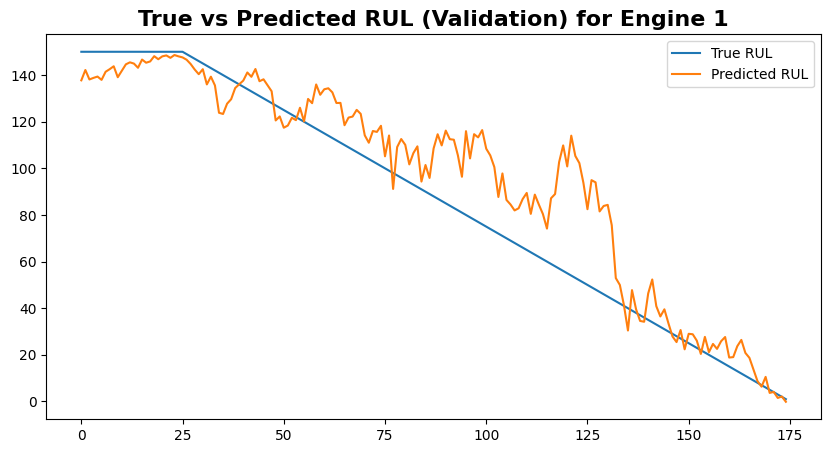

In [201]:
# True VS Predicted Plot
plt.figure(figsize=(10,5))
plt.plot(y_val.iloc[start_idx:end_idx].values, label='True RUL')
plt.plot(val_pred[start_idx:end_idx], label='Predicted RUL')
plt.legend()
plt.title('True vs Predicted RUL (Validation) for Engine 1', fontsize=16, fontweight='bold')
plt.savefig('../reports/plots/true_vs_predicted_xgb_engine_1.png')
plt.show()

The model captures the overall degradation trajectory of the engine reasonably well and successfully follows the long-term downward trend of the Remaining Useful Life (RUL). In particular, prediction accuracy improves noticeably in the critical low-RUL region close to failure, which is especially important for predictive maintenance applications where late-stage degradation detection is most relevant.

At the same time, the prediction curve still exhibits noticeable short-term fluctuations during intermediate degradation phases. This suggests that the model remains somewhat sensitive to local sensor noise and smaller variations in the engineered rolling and slope-based features.

Nevertheless, the predicted trajectory consistently follows the global degradation behavior of the engine and does not lose the overall temporal structure of the failure process.

Overall, the results indicate that the temporal feature engineering pipeline successfully extracts meaningful degradation-related information from the sensor data and already provides a strong foundation for further model optimization and comparison.

### Error Distribution Analysis

The error distribution provides insight into the statistical behavior of the model residuals (`y_true - y_pred`). A distribution centered around zero indicates that the model is approximately unbiased, whereas systematic shifts may reveal consistent overestimation or underestimation of the Remaining Useful Life (RUL).

We now analyze the distribution of prediction errors in order to better understand the overall calibration behavior and robustness of the model across the validation set.

In [22]:
# prediction errors
errors = y_val - val_pred

In [23]:
# basic statistics
print("Mean Error:", np.mean(errors))
print("Std Error :", np.std(errors))
print("Min Error :", np.min(errors))
print("Max Error :", np.max(errors))

Mean Error: 0.639364344862565
Std Error : 19.399738097432394
Min Error : -60.99754333496094
Max Error : 74.8523941040039


The mean prediction error is very close to zero, indicating that the model is approximately unbiased overall and does not systematically overestimate or underestimate the Remaining Useful Life. 

However, the relatively large standard deviation and extreme error values show that prediction quality still varies considerably across different operating conditions and degradation stages.

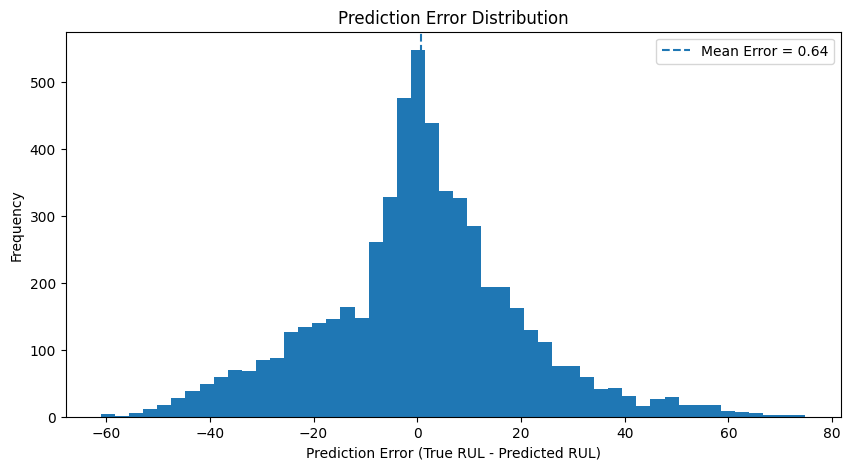

In [202]:
# histogram
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50)
plt.axvline(
    np.mean(errors),
    linestyle="--",
    label=f"Mean Error = {np.mean(errors):.2f}"
)
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error (True RUL - Predicted RUL)")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('../reports/plots/prediction_error_distribution_xgb.png')
plt.show()

The error distribution is centered closely around zero, indicating that the model is approximately unbiased overall and does not systematically overestimate or underestimate the Remaining Useful Life (RUL).

In addition, the distribution appears relatively symmetric and roughly bell-shaped, suggesting that most prediction errors are moderate while larger deviations occur less frequently. However, the visible tails on both sides indicate that the model still produces some substantial prediction errors for certain operating conditions or degradation stages.

We therefore further investigate where the model fails and which RUL regions are primarily responsible for these larger residuals.

### Error Analysis Across RUL Regions

Next, we investigate how prediction errors are distributed across different Remaining Useful Life (RUL) regions. This allows us to analyze whether the model performs differently during early healthy operation, intermediate degradation phases, or near-failure conditions.

In particular, we focus on identifying which RUL regions are associated with the largest prediction errors and whether certain degradation stages are systematically more difficult for the model to predict accurately.

For this purpose, we create a new dataframe called `error_analysis_df` containing the true RUL values, the predicted RUL values, the absolute prediction error, the corresponding engine identifier, and the `time_cycle` at which the prediction error occurred.

This dataframe enables a more detailed investigation of model behavior across different engines and degradation stages.

In [14]:
error_analysis_df = pd.DataFrame({
    'engine_number': val_df['engine_number'].values,
    'time_cycle': val_df['time_cycle'].values,
    'RUL': y_val,
    'predicted_RUL': val_pred,
    'error': y_val - val_pred
}).assign(
    absolute_error=lambda x: np.abs(x['error'])
)

We now further investigate the worst-performing predictions. Here, “worst” refers to predictions with an absolute prediction error greater than 40 cycles.

After creating a filtered dataframe containing these large-error predictions, we analyze for which engines and in which degradation phases (true RUL regions) these substantial deviations primarily occur. For this purpose, we visualize the distributions using histograms.

In [194]:
# top worst predictions
worst_predictions = error_analysis_df[error_analysis_df['absolute_error'] > 40].sort_values('absolute_error', ascending=False)

In [195]:
worst_predictions[
    [
        "engine_number",
        "time_cycle",
        "RUL",
        "predicted_RUL",
        "error",
        "absolute_error"
    ]
]

,engine_number,time_cycle,RUL,predicted_RUL,error,absolute_error
15656,84,116,150,75.147606,74.852394,74.852394
15659,84,119,148,75.454689,72.545311,72.545311
15660,84,120,147,76.619148,70.380852,70.380852
15697,84,157,110,39.732410,70.267590,70.267590
15658,84,118,149,79.496635,69.503365,69.503365
...,...,...,...,...,...,...
12951,70,79,58,98.238617,-40.238617,40.238617
1907,10,154,68,108.189522,-40.189522,40.189522
14920,81,79,150,109.921654,40.078346,40.078346
14948,81,107,133,92.960121,40.039879,40.039879


In [184]:
worst_predictions['RUL'].min()

np.int64(39)

In [185]:
worst_predictions['RUL'].max()

np.int64(150)

In [186]:
worst_predictions['RUL'].mean()

np.float64(109.94006309148266)

C:\Users\tobia\AppData\Local\Temp\ipykernel_16804\2675962618.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


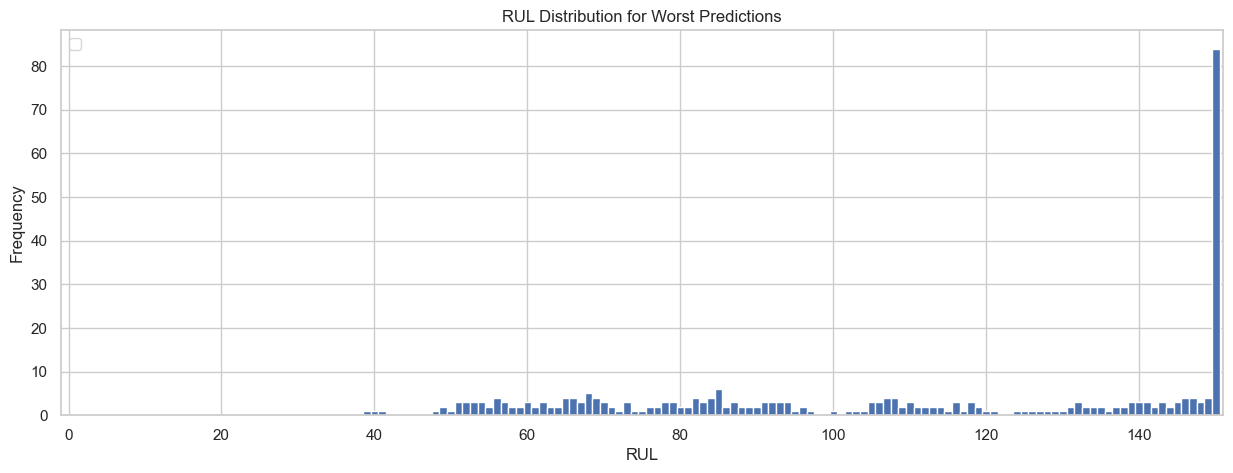

[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  1.  1.  1.  0.  0.  0.  0.  0.  0.  1.  2.  1.  3.  3.  3.
  3.  2.  4.  3.  2.  2.  3.  2.  3.  2.  2.  4.  4.  3.  5.  4.  3.  2.
  1.  3.  1.  1.  2.  2.  3.  3.  2.  2.  4.  3.  4.  6.  2.  3.  2.  2.
  2.  3.  3.  3.  3.  1.  2.  1.  0.  0.  1.  0.  1.  1.  1.  3.  3.  4.
  4.  2.  3.  2.  2.  2.  2.  1.  3.  1.  3.  2.  1.  1.  0.  0.  1.  1.
  1.  1.  1.  1.  1.  2.  3.  2.  2.  2.  1.  2.  2.  3.  3.  3.  2.  3.
  2.  3.  4.  4.  3.  4. 84.]
[ -0.5   0.5   1.5   2.5   3.5   4.5   5.5   6.5   7.5   8.5   9.5  10.5
  11.5  12.5  13.5  14.5  15.5  16.5  17.5  18.5  19.5  20.5  21.5  22.5
  23.5  24.5  25.5  26.5  27.5  28.5  29.5  30.5  31.5  32.5  33.5  34.5
  35.5  36.5  37.5  38.5  39.5  40.5  41.5  42.5  43.5  44.5  45.5  46.5
  47.5  48.5  49.5  50.5  51.5  52.5  53.5  54.5  55.5  56.5  57.5  58.5
  59.5  60.5  61.5  6

In [212]:
plt.figure(figsize=(15, 5))
counts, bins, bars = plt.hist(worst_predictions['RUL'].values, bins=np.arange(-0.5, 151.5, 1))
plt.title('RUL Distribution for Worst Predictions')
plt.xlabel('RUL')
plt.ylabel('Frequency')
plt.xlim(-1, 151)
plt.legend()
plt.savefig('../reports/plots/worst_predictions_xgb_rul_distribution.png')
plt.show()

print(counts)
print(bins)

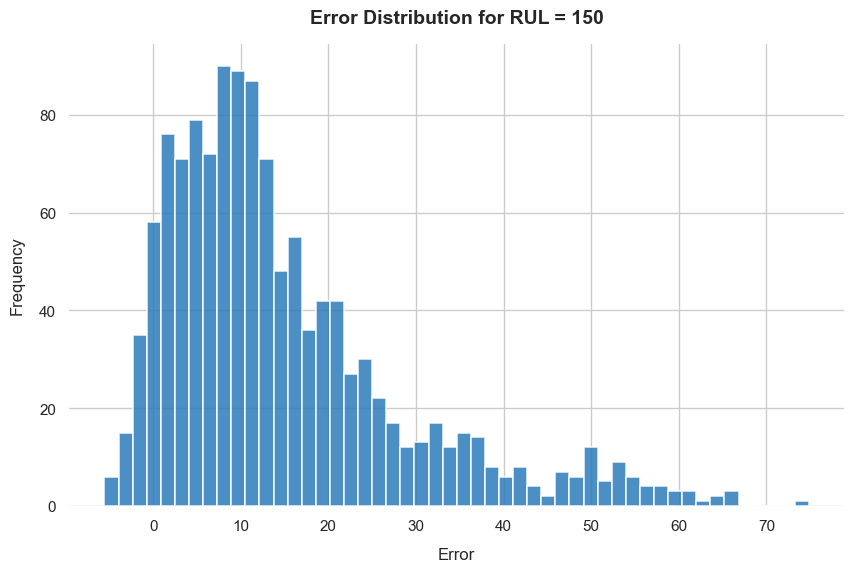

In [213]:
import seaborn as sns
# Optional: Enable a clean, modern design theme
sns.set_theme(style="whitegrid")

# Define the figure size
plt.figure(figsize=(10, 6))

# Filter the data based on RUL threshold
data = error_analysis_df[error_analysis_df['RUL'] == 150]['error']

# Create the styled histogram plot
plt.hist(
    data, 
    bins=50, 
    color='#2b7bba',       # Modern, matte blue instead of default harsh blue
    edgecolor='#ffffff',   # White borders to separate the bins clearly
    linewidth=1.2,         # Thickness of the bin borders
    alpha=0.85,            # Slight transparency for a professional look
    density=False          # Change to True if you want probability density
)

# Add titles and axis labels
plt.title('Error Distribution for RUL = 150', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Error', fontsize=12, labelpad=10)
plt.ylabel('Frequency', fontsize=12, labelpad=10)

# Remove unnecessary outer borders (spines) for a cleaner layout
sns.despine(left=True, bottom=True)

plt.show()

For our histogram of the RUL values corresponding to our worst predictions (defined as predictions with an absolute error greater than 40), we observe the following:

- For low RUL values (RUL < 40), we observe that no worst predictions occur.
- For RUL values between roughly 50 and 149, we observe a relatively constant number of occurrences among the worst predictions.
- However, at a RUL value of 150, we observe a sharp increase in the number of worst predictions, rising from 4 to 84. In the second plot, we further observe that for these cases almost all worst predictions exhibit positive prediction errors, meaning that the model underestimates the RUL (error = y_val - y_pred). Note that 150 corresponds to our RUL clipping threshold.

Hypothesis for this behavior:

Although both training and validation targets are clipped at 150, the observed error pattern can be explained by the structure of the data within this clipped regime.

All engine states with RUL ≥ 150 are mapped to the same target value, which collapses the entire high-RUL region into a single saturated label. This removes all information about differences between moderately high and extremely high RUL values (e.g. 160 vs. 300 cycles). As a result, the model cannot learn the true scale of early-life degradation and only learns a generic representation of a “healthy engine state” associated with the clipped value.

Within this region, sensor readings remain heterogeneous due to operating conditions and noise, while the target is constant. This creates a fundamentally ill-posed learning problem, where many different input states correspond to the same output value. The model therefore learns a broad average over a highly diverse feature space.

Because of this, predictions in the high-RUL regime can deviate substantially from the true values. When true RUL values are significantly above 150, the model systematically outputs values near the learned plateau, which leads to large absolute errors. This explains the strong concentration of errors greater than 40 in this region, as even moderate deviations from the true high RUL values result in large error magnitudes.

This effect directly produces the pronounced peak in the histogram of large errors: many samples share the same clipped target value, but correspond to widely varying true RUL values, leading to consistently large discrepancies between prediction and ground truth.

However, this behavior is acceptable in our setting, since the primary objective is accurate prediction in the low-RUL regime close to failure. In this critical region, the model performs significantly better and provides reliable degradation estimates, which is most important for predictive maintenance applications.

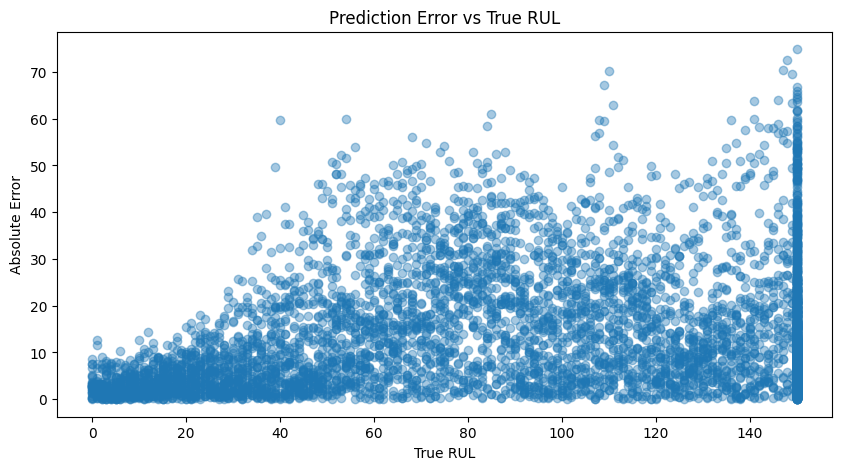

In [53]:
plt.figure(figsize=(10,5))

plt.scatter(
    error_analysis_df['RUL'],
    error_analysis_df['absolute_error'],
    alpha=0.4
)

plt.xlabel('True RUL')
plt.ylabel('Absolute Error')

plt.title('Prediction Error vs True RUL')

plt.show()

For our scatter plot of true RUL values against absolute prediction errors, we observe the following:

- For critical RUL regions (RUL < 25), the model shows generally low absolute errors, on average below approximately 10 cycles. This behavior is expected, since in this regime the remaining lifetime is already very small and there is limited range for large deviations in the predictions. Nevertheless, this performance is notably strong for a non-hyperparameter-optimized XGBoost model.

- In the intermediate RUL range (approximately 40–149), errors are roughly evenly distributed across the region. Most of the errors remain relatively small, typically below 25 cycles, indicating stable model performance in this mid-degradation phase.

- The behavior at RUL = 150 has already been discussed and is explained by the clipping effect, which leads to a concentration of errors in the high-RUL regime.

### Errors Per Engine

In this section, we analyze the distribution of prediction errors across the engines in the validation set. For engines with the largest errors, we investigate the corresponding sensor trajectories and engineered features in order to determine whether the high error stems from weak or noisy signal patterns, or from a lack of clearly learnable degradation behavior.



Before investigating individual engines, we define a visualization function that combines the most important engineered features with the true and predicted Remaining Useful Life (RUL) trajectory of a selected engine.

To keep the visualization interpretable, only the five most important features (based on XGBoost feature importance using the gain metric) are displayed.

As we cannot include all features in the visualization at once, we focus on the features that contribute most strongly to reducing the loss during training and therefore have the highest predictive relevance for the model’s decision-making process.

Since these features operate on different numerical scales, each feature is normalized to the range [0, 1] within the selected engine.

The resulting plot allows us to simultaneously inspect:

- the evolution of the most influential features over the engine lifetime,
- the true and predicted RUL trajectories,
- potential degradation patterns in the features,
- and the relationship between feature behavior and prediction quality.

This visualization serves as the primary tool for our subsequent engine-level error analysis.

In [35]:
# 1. Feature Importances als Dictionary holen (Beispiel mit 'gain')
importance_dict = xgb_model.get_booster().get_score(importance_type='gain')

# 2. In ein Pandas DataFrame umwandeln
df_importance = pd.DataFrame(
    list(importance_dict.items()), 
    columns=['Feature', 'Importance']
)
df_importance['Importance_Pct'] = (df_importance['Importance'] / df_importance['Importance'].sum()) * 100

df_importance = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)

pd.set_option('display.max_rows', 5)

df_importance

,Feature,Importance,Importance_Pct
0,sensor_3_roll_mean_17,336094.718750,17.853646
1,sensor_21,226515.218750,12.032687
...,...,...,...
76,setting_2,823.981567,0.043771
77,sensor_17_slope_5,737.323059,0.039167


In [36]:
target_features = df_importance.iloc[0:5]['Feature'].to_list()

In [38]:
def plot_engine_analysis(engine_number, features_to_plot=target_features):
    """
    Plots normalized features and predicted RUL for a specific engine number.
    """
    cmap = plt.get_cmap('viridis')
    fig, ax1 = plt.subplots(figsize=(12, 6)) 

    # Filter datasets dynamically based on the input engine number
    engine_data = df[df['engine_number'] == engine_number]
    engine_errors = error_analysis_df[error_analysis_df['engine_number'] == engine_number]  

    n_features = len(features_to_plot)

    # Plot features on the FIRST y-axis (left)
    for idx, target_feature in enumerate(features_to_plot):
        values = engine_data[target_feature]
        
        if values.max() != values.min():
            normalized_values = (values - values.min()) / (values.max() - values.min())
        else:
            normalized_values = values - values.min()
            
        color_idx = idx / (n_features - 1) if n_features > 1 else 0.0
        farbe = cmap(color_idx)
        
        ax1.plot(engine_data['time_cycle'], normalized_values, label=f"{target_feature} (norm)", color=farbe, alpha=0.7)

    # Configure the left Y-axis
    ax1.set_xlabel('Time Cycle')
    ax1.set_ylabel('Normalized Feature Values (0 - 1)', color='black')
    ax1.tick_params(axis='y', labelcolor='black')

    # Create a SECOND y-axis sharing the same x-axis for the RUL
    ax2 = ax1.twinx()  
    ax2.plot(
        engine_errors['time_cycle'],
        engine_errors['RUL'],
        label='True RUL',
        color='black',
        linewidth=2
    )  
    ax2.plot(engine_errors['time_cycle'], engine_errors['predicted_RUL'], label='Predicted RUL', color='red', linewidth=2.5)

    # Configure the right Y-axis
    ax2.set_ylabel('Predicted RUL (Cycles)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')  

    # Dynamic title based on engine number
    plt.title(f'Engine {engine_number} - Normalized Features vs Predicted RUL')

    # Combine legends from both axes and move it outside to the right
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.15, 1), fontsize='small')

    plt.tight_layout()
    plt.savefig(f'../reports/plots/engine_{engine_number}_xgb.png')
    plt.show()


To gain deeper insight into the model’s failure behavior, we select two representative engines from the validation set for detailed visualization and analysis.

The selection is based on error statistics computed across all engines, rather than arbitrary sampling, in order to capture different types of prediction failures.

Specifically, we choose:

- **Engine with the highest Mean Absolute Error (MAE):**  
  This engine represents the overall worst-case prediction performance of the model. It allows us to analyze where and why the model produces the largest deviations from the true RUL trajectory.

- **Engine with the highest error variability (standard deviation of the error):**  
  This engine captures instability in predictions over time. It helps identify cases where the model does not fail consistently, but instead shows strong fluctuations in prediction quality across different degradation phases.

Together, these two engines provide complementary perspectives on model performance: one focusing on overall prediction accuracy, and the other on temporal stability of the predictions.

#### Analysis of the Engine with the Highest Mean Absolute Error

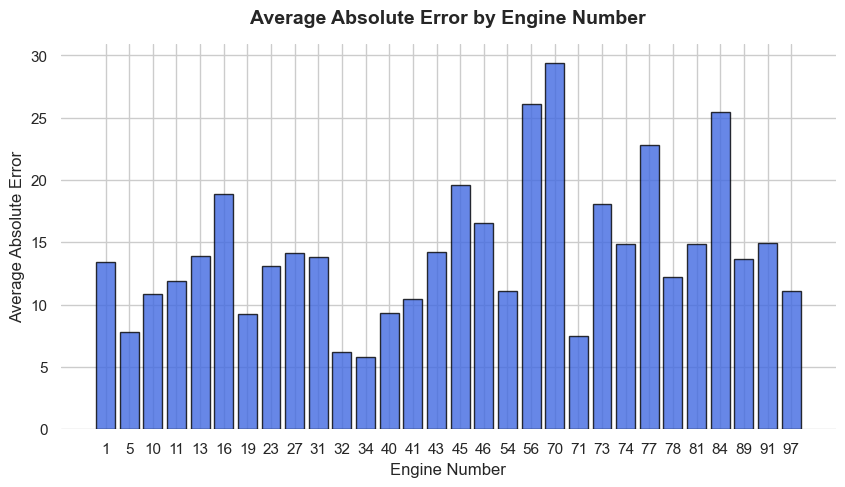

In [32]:
# Optional: Enable a clean, modern design theme
sns.set_theme(style="whitegrid")

avg_error_per_engine = (
    error_analysis_df
    .groupby('engine_number')['absolute_error']
    .mean()
)

plt.figure(figsize=(10,5))

plt.bar(
    avg_error_per_engine.index.astype(str),
    avg_error_per_engine.values,
    color='royalblue',
    edgecolor='black',
    alpha=0.8
)

plt.xlabel('Engine Number')
plt.ylabel('Average Absolute Error')
plt.title('Average Absolute Error by Engine Number',
          fontsize=14,
          fontweight='bold',
          pad=15)


sns.despine(left=True, bottom=True)

plt.savefig('../reports/plots/average_absolute_error_by_engine_number_xgb_model.png')
plt.show()


We observe that only a few engines exhibit a mean absolute error above 20 cycles. For our error-by-engine analysis, we focus on engine 70 as the engine with the highest mean absolute error.

We expect that the high error in this case is primarily driven by a systematic bias rather than random fluctuations, as the prediction error appears to be consistently shifted over time instead of being highly volatile.

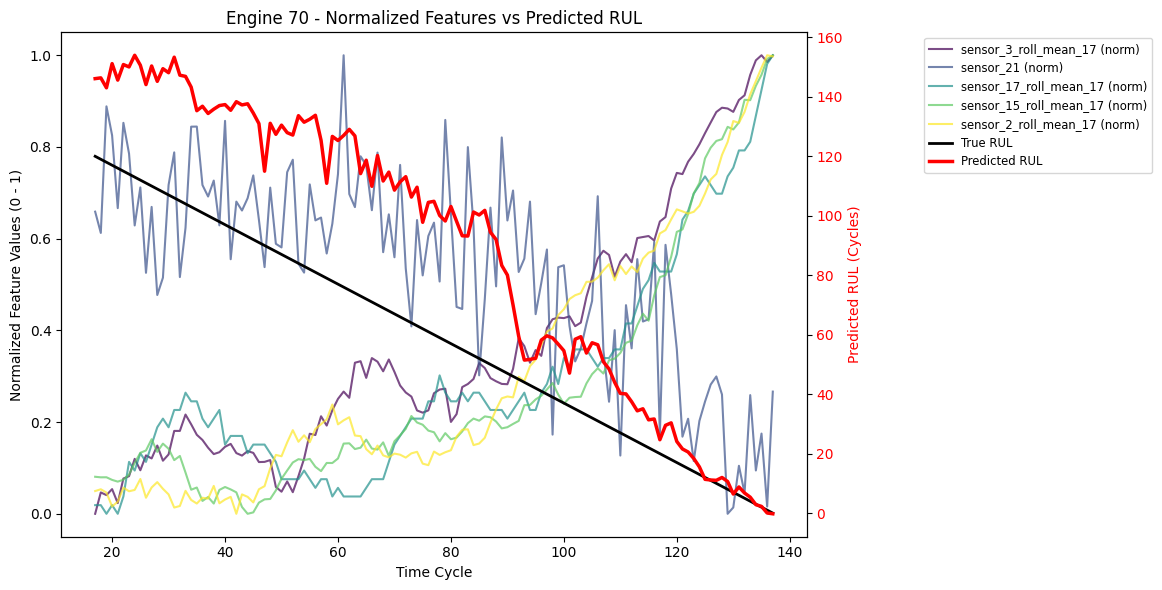

In [39]:
plot_engine_analysis(70)

In [ ]:
# maximum time cycles of engine 70
df[df['engine_number'] == 70]['time_cycle'].max()

np.int64(137)

For engine 70 (engine with highest MAE), we observe the following:

- The predicted RUL (in red) captures the overall downward trend of the true RUL, indicating that the model has learned the general degradation behavior, though it systematically overestimates the RUL in the first half of the lifecycle.

- The largest deviations occur mainly in the early to mid-life phase. Before approximately cycle 85, residuals are exceptionally high. This is because the true RUL decreases linearly from the very beginning (lacking an initial plateau), whereas the model predicts a flat, high RUL between 140 and 150 cycles. This leads to a rapid correction phase between cycles 85 and 95, where the predicted RUL drops sharply to catch up. From cycle 110 onwards, the prediction error decreases significantly and aligns almost perfectly with the true RUL.

- This pattern is closely reflected in the feature behavior: the smoothed sensors (`sensor_2`, `sensor_3`, `sensor_15`, `sensor_17`) remain flat and do not yet exhibit clear degradation trends until around cycle 85, which tricks the model into predicting a high RUL. Meanwhile, `sensor_21` remains notably noisy and volatile because it lacks a rolling mean (unlike the other features), showing an inverse downward trend with a pronounced spike around cycle 60.

- The predicted curve itself does not exhibit chaotic instability or random jumps; instead, it remains relatively smooth with a clear downward trajectory, showing a steep but continuous adjustment in the mid-life phase and only minor fluctuations around the main trajectory.

Overall, the high error for this engine is primarily driven by the early systematic overestimation and delayed sensor degradation trends, rather than a failure of the model to capture the actual critical degradation dynamics in the late lifecycle.

#### Analysis of the Engine with the Highest Error Variability

Having analyzed the engine with the highest mean absolute error (MAE), we now investigate a second engine to explore a different type of model behavior.

While the MAE identifies the engine on which the model performs worst overall, it does not necessarily capture prediction stability. Therefore, we select the engine with the highest standard deviation of the prediction error.

A high error standard deviation indicates that the prediction quality varies substantially throughout the engine lifetime. By analyzing this engine, we can investigate whether the model struggles with noisy sensor signals, unstable degradation patterns, or abrupt changes in operating behavior.

Together, the highest-MAE engine and the highest-error-variability engine provide a more comprehensive understanding of the model's strengths and weaknesses at the individual engine level.

In [15]:
error_analysis_df

,engine_number,time_cycle,RUL,predicted_RUL,error,absolute_error
0,1,17,150,137.753952,12.246048,12.246048
1,1,18,150,142.182892,7.817108,7.817108
2,1,19,150,138.128891,11.871109,11.871109
3,1,20,150,138.799118,11.200882,11.200882
4,1,21,150,139.368362,10.631638,10.631638
...,...,...,...,...,...,...
18533,97,198,4,4.938998,-0.938998,0.938998
18534,97,199,3,4.573069,-1.573069,1.573069
18535,97,200,2,4.046457,-2.046457,2.046457
18536,97,201,1,3.239635,-2.239635,2.239635


In [26]:
std_error_df = (
    error_analysis_df.groupby('engine_number')['error']
    .std()
    .sort_values(ascending=False)
)


In [27]:
std_error_df

engine_number
46    21.024071
84    20.367203
56    18.758274
31    18.281907
43    17.321346
70    16.793388
78    16.023312
1     15.646842
89    15.546318
81    15.318883
73    14.642747
77    14.530900
74    14.430246
11    14.336651
16    13.990532
97    13.736233
10    13.145872
45    12.763995
54    12.063104
23    11.800658
91    11.415996
19    11.280455
41    11.035991
27    10.713200
13    10.475491
71     9.554316
5      8.364462
40     8.307095
34     7.611449
32     6.657215
Name: error, dtype: float64

In [23]:
len(std_error_df)

30

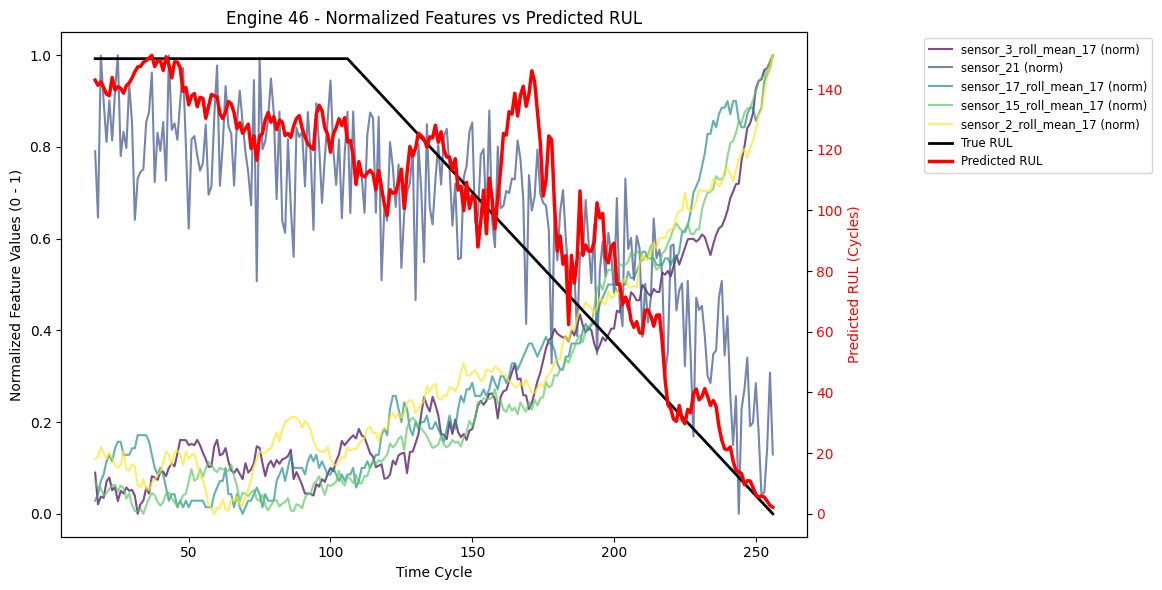

In [40]:
plot_engine_analysis(46)

In [41]:
target_features

['sensor_3_roll_mean_17',
 'sensor_21',
 'sensor_17_roll_mean_17',
 'sensor_15_roll_mean_17',
 'sensor_2_roll_mean_17']

Interpretation of the RUL Prediction Plot (Engine 46)

Summary of Model Behavior  
Engine 46 shows noticeable fluctuations in predicted RUL in the early and mid-life phases up to approximately cycle 185.

- Early and mid-life phase (up to cycle ~185):  
  Absolute errors remain mostly moderate (typically <20 cycles), but predictions are highly variable rather than consistently inaccurate. Up to about cycle 110, the true RUL is capped at ~150 cycles due to the piecewise linear RUL definition, where values above 150 are clipped. In this phase, the model learns a near-constant target while sensor signals provide limited degradation information.

- Prediction spike:  
  Between cycles ~165–175, a strong spike occurs where the model deviates significantly from the true RUL, with errors up to ~60 cycles (prediction >140 vs. true ~80). This indicates a short instability during a transitional degradation phase.

- Late phase (from cycle 185 onward):  
  Predictions become stable and closely follow the true RUL, with clearly reduced error. This shows strong performance in the most critical predictive maintenance region.

Feature Perspective and Sensor Analysis  
- Smoothed sensors (`sensor_2`, `sensor_3`, `sensor_15`, `sensor_17`) show clear increasing degradation trends due to rolling mean smoothing (window 17), reducing noise.  
- `sensor_21` shows a strong downward trend and remains unsmoothed, leading to higher short-term variability. It is also one of the most important features (gain), likely contributing to early instability.

Conclusion  
Despite early instability driven mainly by noisy and highly influential features, the model is robust in the late lifecycle phase, where accurate RUL prediction is most important.

## Removing Redundant Features

At this stage, we have already trained and evaluated our initial XGBoost model using the complete engineered feature set. The model achieved strong predictive performance, and we have thoroughly analyzed its behavior through validation metrics, prediction plots, error distributions, and engine-level error analysis.

Before proceeding to feature importance analysis and model interpretation, however, we investigate the presence of redundant features in our engineered feature set.

Due to the extensive feature engineering process (e.g., rolling means, rolling standard deviations, and slope features), many variables are expected to be highly correlated with one another. Such multicollinearity can negatively affect model interpretability, even for tree-based models such as XGBoost.

In particular, highly correlated features may lead to:

1. **Distorted Feature Importance:**
   The model may distribute predictive importance across multiple highly similar features, making it difficult to identify the truly relevant degradation signals.

2. **Misleading SHAP Explanations:**
   Correlated features can receive substantial SHAP importance even if the model primarily relies on a related feature for its decision-making process.

The objective of this analysis is therefore not to improve the predictive performance of the model, but to obtain a cleaner and more interpretable feature set before performing feature importance and SHAP analyses.

To achieve this, we first analyze feature correlations and remove highly redundant variables based on both statistical evidence and domain knowledge. The model will then be retrained on the reduced feature set before continuing with the interpretation stage.

Afterward, during the feature importance and SHAP analyses, we will additionally identify and remove features that contribute little or no predictive value to the model. Together, these two steps allow us to construct a compact feature set that is both highly predictive and straightforward to interpret.



In [36]:
# 1. Calculate the correlation matrix for our specific sensor features
corr_matrix = X_train.corr(method='pearson').abs()

In [37]:
# 2. Isolate the upper triangle to avoid duplicate feature pairs
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Identify all features that have a correlation greater than 85% with another feature
threshold = 0.85
to_drop_automatically = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

print(f"Suggestion: Remove {len(to_drop_automatically)} out of {len(X_train.columns)} features.")

Suggestion: Remove 17 out of 78 features.


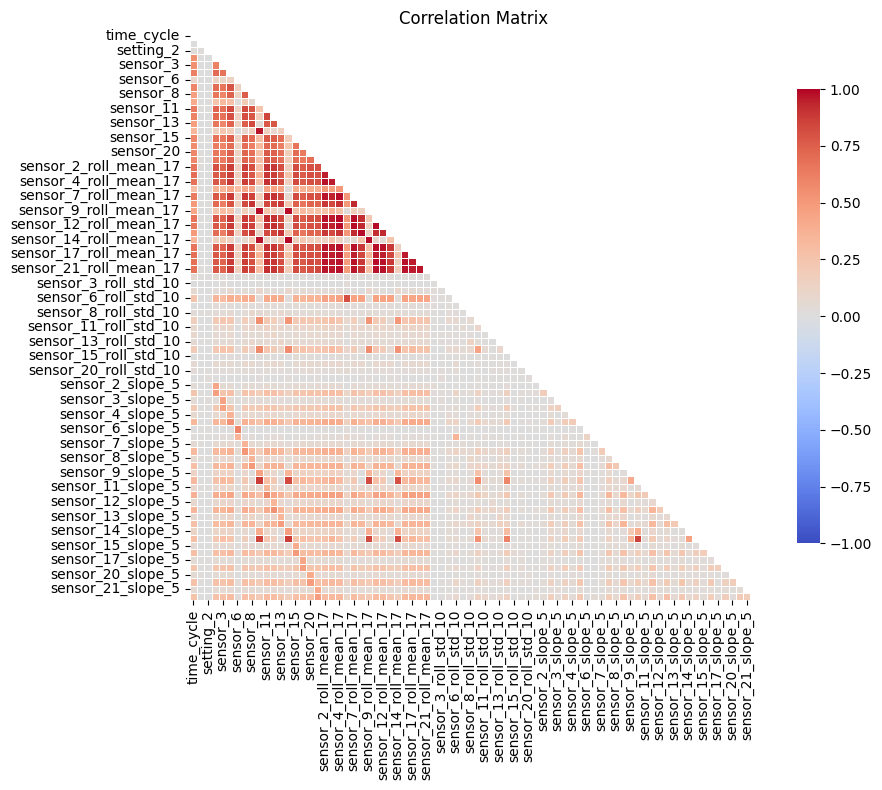

In [19]:
# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set figure size
plt.figure(figsize=(10, 8))

# Create heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,          # Hide upper triangle
    annot=False,         
    fmt=".2f",          # Display values with 2 decimal places
    cmap="coolwarm",    # Color palette
    vmin=-1, vmax=1,    # Correlation range
    square=True,        # Make cells square
    linewidths=0.5,     # Add lines between cells
    cbar_kws={"shrink": 0.8}  # Reduce color bar size
)

# Add title
plt.title("Correlation Matrix")

# Improve layout
plt.tight_layout()

# Display plot
plt.show()

In [38]:
# 2. Isolate the upper triangle to avoid duplicate feature pairs
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [39]:
# 3. Identify all features that have a correlation greater than 85% with another feature
threshold = 0.85
to_drop_automatically = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

In [40]:
to_drop_automatically

['sensor_14',
 'sensor_2_roll_mean_17',
 'sensor_3_roll_mean_17',
 'sensor_4_roll_mean_17',
 'sensor_7_roll_mean_17',
 'sensor_8_roll_mean_17',
 'sensor_9_roll_mean_17',
 'sensor_11_roll_mean_17',
 'sensor_12_roll_mean_17',
 'sensor_13_roll_mean_17',
 'sensor_14_roll_mean_17',
 'sensor_15_roll_mean_17',
 'sensor_17_roll_mean_17',
 'sensor_20_roll_mean_17',
 'sensor_21_roll_mean_17',
 'sensor_9_slope_17',
 'sensor_14_slope_17']

In [24]:
print(f"Suggestion: Remove {len(to_drop_automatically)} out of {len(X_train.columns)} features.")

Suggestion: Remove 17 out of 78 features.


We observe that high correlations do not only occur between different transformations of the same sensor, but also between features originating from different sensors. This is expected in a physical system such as an engine, where subsystems are inherently coupled. For example, an increase in turbine temperature can directly influence compressor pressure, meaning that multiple sensors may respond simultaneously to the same underlying degradation process.

This creates an important challenge for automated feature selection methods. A purely statistical approach only evaluates numerical similarity. For instance, if `sensor_2_roll_mean_17` and `sensor_4_roll_mean_17` show a correlation of 0.9, a naive algorithm would remove one of them. However, this ignores the fact that both features may encode different physical behaviors and operate on different degradation time scales. One sensor might react early in the lifecycle, while another becomes informative only in later stages.

To address this, we distinguish between two types of redundancy:

- **1. Safe removal (same sensor, different transformation):**  
  If two features originate from the same sensor but represent different transformations (e.g., raw value vs. rolling mean), we remove the less stable or less informative variant.  
  Example: If `sensor_14` is highly correlated with `sensor_14_roll_mean_17`, we remove the raw signal and keep the smoothed version. Similarly, if multiple slope variants exist (e.g., window 5 vs. window 17), we keep the more stable long-window version.

- **2. Careful retention (different sensors):**  
  If two highly correlated features originate from different sensors, we generally retain both features. Although they may be statistically correlated, they often capture different physical aspects of the system. Tree-based models such as XGBoost are robust to multicollinearity in this case and can exploit subtle differences in signal behavior across sensors.

Overall, this strategy ensures that we reduce redundancy without discarding physically meaningful information, preserving both interpretability and predictive power of the model.

In [41]:
# We identify which features are colliding with each other, grouped by logic
high_corr = (upper_tri > threshold).stack()
high_corr_pairs = high_corr[high_corr == True].index.tolist()
high_corr_pairs

[('sensor_4', 'sensor_2_roll_mean_17'),
 ('sensor_4', 'sensor_3_roll_mean_17'),
 ('sensor_4', 'sensor_4_roll_mean_17'),
 ('sensor_4', 'sensor_7_roll_mean_17'),
 ('sensor_4', 'sensor_11_roll_mean_17'),
 ('sensor_4', 'sensor_12_roll_mean_17'),
 ('sensor_4', 'sensor_15_roll_mean_17'),
 ('sensor_4', 'sensor_17_roll_mean_17'),
 ('sensor_4', 'sensor_20_roll_mean_17'),
 ('sensor_4', 'sensor_21_roll_mean_17'),
 ('sensor_7', 'sensor_2_roll_mean_17'),
 ('sensor_7', 'sensor_3_roll_mean_17'),
 ('sensor_7', 'sensor_4_roll_mean_17'),
 ('sensor_7', 'sensor_7_roll_mean_17'),
 ('sensor_7', 'sensor_11_roll_mean_17'),
 ('sensor_7', 'sensor_12_roll_mean_17'),
 ('sensor_7', 'sensor_15_roll_mean_17'),
 ('sensor_7', 'sensor_17_roll_mean_17'),
 ('sensor_7', 'sensor_20_roll_mean_17'),
 ('sensor_7', 'sensor_21_roll_mean_17'),
 ('sensor_8', 'sensor_7_roll_mean_17'),
 ('sensor_8', 'sensor_8_roll_mean_17'),
 ('sensor_8', 'sensor_12_roll_mean_17'),
 ('sensor_8', 'sensor_13_roll_mean_17'),
 ('sensor_9', 'sensor_14')

In [42]:
# Helper function to extract the base sensor name
# e.g. 'sensor_12_roll_mean_17' -> 'sensor_12'

def get_base_sensor(name):
        parts = name.split('_')
        if len(parts) >= 2 and parts[0] == 'sensor':
            return f"{parts[0]}_{parts[1]}"
        return name

In [43]:
# test
get_base_sensor('sensor_12_roll_mean_17')

'sensor_12'

In [44]:
print("--- ANALYSIS OF CORRELATED SENSOR PAIRS ---")

for feat1, feat2 in high_corr_pairs:
    
    base1 = get_base_sensor(feat1)
    base2 = get_base_sensor(feat2)
    score = corr_matrix.loc[feat1, feat2]

    if base1 == base2:
        print(
            f"✓ REDUNDANCY (same sensor): '{feat1}' <-> '{feat2}' "
            f"(r = {score:.2f}) -> MARKED FOR REMOVAL"
        )
    else:
        print(
            f"! PHYSICAL COUPLING (different sensors): '{feat1}' <-> '{feat2}' "
            f"(r = {score:.2f}) -> KEEP IN MODEL"
        )


--- ANALYSIS OF CORRELATED SENSOR PAIRS ---
! PHYSICAL COUPLING (different sensors): 'sensor_4' <-> 'sensor_2_roll_mean_17' (r = 0.87) -> KEEP IN MODEL
! PHYSICAL COUPLING (different sensors): 'sensor_4' <-> 'sensor_3_roll_mean_17' (r = 0.87) -> KEEP IN MODEL
✓ REDUNDANCY (same sensor): 'sensor_4' <-> 'sensor_4_roll_mean_17' (r = 0.90) -> MARKED FOR REMOVAL
! PHYSICAL COUPLING (different sensors): 'sensor_4' <-> 'sensor_7_roll_mean_17' (r = 0.88) -> KEEP IN MODEL
! PHYSICAL COUPLING (different sensors): 'sensor_4' <-> 'sensor_11_roll_mean_17' (r = 0.88) -> KEEP IN MODEL
! PHYSICAL COUPLING (different sensors): 'sensor_4' <-> 'sensor_12_roll_mean_17' (r = 0.88) -> KEEP IN MODEL
! PHYSICAL COUPLING (different sensors): 'sensor_4' <-> 'sensor_15_roll_mean_17' (r = 0.88) -> KEEP IN MODEL
! PHYSICAL COUPLING (different sensors): 'sensor_4' <-> 'sensor_17_roll_mean_17' (r = 0.87) -> KEEP IN MODEL
! PHYSICAL COUPLING (different sensors): 'sensor_4' <-> 'sensor_20_roll_mean_17' (r = 0.88) -> K

In [ ]:
# ✓ REDUNDANCY (same sensor): 'sensor_4' <-> 'sensor_4_roll_mean_17' (r = 0.90) -> MARKED FOR REMOVAL
# ✓ REDUNDANCY (same sensor): 'sensor_7' <-> 'sensor_7_roll_mean_17' (r = 0.89) -> MARKED FOR REMOVAL
# ✓ REDUNDANCY (same sensor): 'sensor_8' <-> 'sensor_8_roll_mean_17' (r = 0.90) -> MARKED FOR REMOVAL
# ✓ REDUNDANCY (same sensor): 'sensor_9' <-> 'sensor_9_roll_mean_17' (r = 0.98) -> MARKED FOR REMOVAL
# ✓ REDUNDANCY (same sensor): 'sensor_9' <-> 'sensor_9_slope_17' (r = 0.87) -> MARKED FOR REMOVAL
# ✓ REDUNDANCY (same sensor): 'sensor_11' <-> 'sensor_11_roll_mean_17' (r = 0.93) -> MARKED FOR REMOVAL
# ✓ REDUNDANCY (same sensor): 'sensor_12' <-> 'sensor_12_roll_mean_17' (r = 0.91) -> MARKED FOR REMOVAL
# ✓ REDUNDANCY (same sensor): 'sensor_13' <-> 'sensor_13_roll_mean_17' (r = 0.90) -> MARKED FOR REMOVAL
# ✓ REDUNDANCY (same sensor): 'sensor_14' <-> 'sensor_14_roll_mean_17' (r = 0.99) -> MARKED FOR REMOVAL
# ✓ REDUNDANCY (same sensor): 'sensor_14' <-> 'sensor_14_slope_17' (r = 0.87) -> MARKED FOR REMOVAL
# ✓ REDUNDANCY (same sensor): 'sensor_15' <-> 'sensor_15_roll_mean_17' (r = 0.85) -> MARKED FOR REMOVAL

In [10]:
# We populate this list ONLY with redundant variants of the SAME sensor
features_to_remove = [
    'sensor_4',   # Removed raw value; highly redundant with sensor_4_roll_mean_17 (r=0.90)
    'sensor_7',   # Removed raw value; highly redundant with sensor_7_roll_mean_17 (r=0.89)
    'sensor_8',   # Removed raw value; highly redundant with sensor_8_roll_mean_17 (r=0.90)
    'sensor_9',   # Removed raw value; highly redundant with both roll_mean_17 (r=0.98) and slope_17 (r=0.87)
    'sensor_11',  # Removed raw value; highly redundant with sensor_11_roll_mean_17 (r=0.93)
    'sensor_12',  # Removed raw value; highly redundant with sensor_12_roll_mean_17 (r=0.91)
    'sensor_13',  # Removed raw value; highly redundant with sensor_13_roll_mean_17 (r=0.90)
    'sensor_14',  # Removed raw value; near-perfect redundancy with sensor_14_roll_mean_17 (r=0.99) and slope_17 (r=0.87)
    'sensor_15'   # Removed raw value; highly redundant with sensor_15_roll_mean_17 (r=0.85)
]

In [11]:
# We create cleaned datasets without the selected features
X_train_clean = X_train.drop(columns=features_to_remove)

In [12]:
X_val_clean = X_val.drop(columns=features_to_remove)

## XGBoost Model Retraining

After removing several redundant raw sensor features, we retrain the XGBoost model using the reduced feature set to evaluate whether predictive performance changes compared to the initial model trained on the complete engineered dataset.

Since the removed features were identified as highly redundant with more informative engineered features (primarily rolling means), we expect the overall predictive performance to remain largely unchanged. A stable validation performance would confirm that these raw sensor values contributed little additional information, while the reduced feature set improves model interpretability and prepares the model for a more reliable feature importance and SHAP analysis.

In [19]:
xgb_model = joblib.load('../models/xgb_model.pkl')

In [20]:
xgb_model_retrained = clone(xgb_model)

In [23]:
xgb_model_retrained.fit(X_train_clean, y_train, eval_set=[(X_val_clean, y_val)], verbose=100)

[0]	validation_0-rmse:48.19556
[100]	validation_0-rmse:20.44380
[200]	validation_0-rmse:19.60073
[300]	validation_0-rmse:19.54234
[331]	validation_0-rmse:19.55197


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,0.6
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.4
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [25]:
val_pred = xgb_model_retrained.predict(X_val_clean)

rmse_val = np.sqrt(mean_squared_error(y_val, val_pred))
mae_val = mean_absolute_error(y_val, val_pred)
r2_val = r2_score(y_val, val_pred)

print("=== Validation Performance (Clipped RUL) ===")
print(f"RMSE: {rmse_val:.2f} cycles (Average squared deviation)")
print(f"MAE:  {mae_val:.2f} cycles (Average absolute error)")
print(f"R²:   {r2_val:.4f} (Variance explained by the model)")

=== Validation Performance (Clipped RUL) ===
RMSE: 19.54 cycles (Average squared deviation)
MAE:  14.49 cycles (Average absolute error)
R²:   0.8433 (Variance explained by the model)


### Interpretation of the Retrained Model Performance

| Metric | Original Model | Retrained Model | Change |
|--------|---------------:|----------------:|-------:|
| RMSE | **19.41** | **19.54** | +0.13 |
| MAE | **14.32** | **14.49** | +0.17 |
| R² | **0.8454** | **0.8433** | −0.0021 |

The retrained XGBoost model achieves almost identical predictive performance to the original model trained on the complete engineered feature set.

The RMSE increases by only 0.13 cycles, the MAE by 0.17 cycles, and the R² decreases by 0.0021. These differences are very small and indicate that removing the redundant raw sensor features has only a negligible impact on predictive accuracy.

The slight reduction in performance is expected, as even highly redundant features may still contain small amounts of complementary information that the model can exploit. Removing them therefore involves a minor trade-off between predictive performance and model simplicity.

Given the negligible performance loss, the reduced feature set represents a favorable compromise: it preserves virtually all predictive power while reducing redundancy and providing a cleaner basis for the subsequent feature importance and SHAP analyses.

## Feature Importance Analysis

Now we come to the stage that motivated the removal of redundant features: the feature importance analysis.

After cleaning the feature set and retraining the XGBoost model, we investigate which engineered features contribute most strongly to the prediction of the Remaining Useful Life (RUL).

It is worth noting that **XGBoost Gain Importance** has already been used earlier in our analysis. During the engine-level error analysis, we selected and visualized only the features with the highest gain values in order to understand which sensor signals primarily influenced the model's predictions. We now extend this idea by systematically analyzing the importance of the entire feature set.

We perform two complementary analyses:

* **XGBoost Gain Importance**

  * Measures how much each feature contributes to reducing the training loss across all tree splits.
  * Provides a global ranking of the most influential features.
  * Serves as the primary criterion for identifying features with little predictive value.

* **TreeSHAP (SHAP Values)**

  * Quantifies the contribution of each feature to individual predictions.
  * Explains not only **which** features are important, but also **how** they influence the predicted RUL.
  * Validates that the most important features identified by the model are physically meaningful and consistently influential across predictions.

Based primarily on the XGBoost Gain Importance, we will subsequently remove features with negligible predictive contribution and retrain the model once more. The TreeSHAP analysis is then used to verify that the resulting feature set remains both highly predictive and physically interpretable.

Together, these analyses provide both a global understanding of feature importance and a detailed explanation of the model's decision-making process.



In [27]:
gain_dict_xgb_model_retrained = xgb_model_retrained.get_booster().get_score(importance_type='gain')

In [29]:
gain_df = pd.DataFrame(list(gain_dict_xgb_model_retrained.items()), columns=['Feature', 'Gain'])

In [30]:
gain_df = gain_df.sort_values(by='Gain', ascending=False).reset_index(drop=True)

In [31]:
gain_df

,Feature,Gain
0,sensor_17_roll_mean_17,248501.109375
1,sensor_15_roll_mean_17,188461.609375
2,sensor_2_roll_mean_17,142522.703125
3,sensor_3_roll_mean_17,129071.000000
4,sensor_4_roll_mean_17,89472.664062
...,...,...
63,sensor_13_slope_5,1416.541016
64,sensor_2_slope_5,1355.495483
65,setting_1,1003.592285
66,setting_2,699.177246


Now that we have computed the Gain-based feature importance from the XGBoost model, a straightforward approach would be to manually define a threshold and remove all features below that value.

However, this approach is inherently arbitrary and may lead to suboptimal feature selection, as it does not consider the actual impact of feature removal on model performance.

Instead, we follow a more robust and widely used machine learning practice: we treat feature selection as a hyperparameter optimization problem. Specifically, we evaluate different gain thresholds, train models on the resulting feature subsets, and use cross-validation to identify the configuration that achieves the best predictive performance.

In the Scikit-Learn ecosystem, this procedure is typically implemented using `SelectFromModel` in combination with `GridSearchCV` or `RandomizedSearchCV`. This allows us to systematically test different levels of feature pruning while ensuring that model evaluation remains statistically reliable through cross-validation.

This approach ensures that feature selection is not based on subjective choices, but is directly guided by validation performance, leading to a more optimal and reproducible feature set.

In [34]:
xgb_model = joblib.load('../models/xgb_model.pkl')

In [78]:
xgb_for_selector = clone(xgb_model).set_params(importance_type="gain", early_stopping_rounds=None)

In [79]:
xgb_for_final_model = clone(xgb_model).set_params(early_stopping_rounds=None)

In [83]:
feature_pipeline = Pipeline(
    [
        (
            "selector",
            SelectFromModel(estimator=xgb_for_selector),
        ),
        ("model", xgb_for_final_model),
    ]
)

To determine suitable candidate thresholds for feature selection, we first analyze the distribution of the gain-based feature importances.

Importantly, this analysis is used solely to understand the general scale and distribution of the feature importances. It is not used to directly optimize or tune the final model parameters, in order to avoid information leakage into the cross-validation process.

Instead of selecting arbitrary cutoff values, we inspect several statistical properties of the gain values, including the minimum, maximum, mean, and median, as well as the overall distribution via a histogram.

This exploratory analysis helps us understand how feature importance is distributed across the engineered feature set and whether there are natural gaps or clusters in importance values. Based on these insights, we can define meaningful threshold ranges that will later be evaluated systematically using cross-validation.

This ensures that the final selection of features is both data-driven and robust, rather than based on subjective assumptions.

In [44]:
np.min(gain_df['Gain'])

np.float64(513.1748046875)

In [45]:
np.max(gain_df['Gain'])

np.float64(248501.109375)

In [47]:
np.median(gain_df['Gain'])

np.float64(4383.928466796875)

In [54]:
np.mean(gain_df['Gain'])

np.float64(22188.688219855812)

(array([36.,  7.,  5.,  2.,  6.,  2.,  0.,  1.,  2.,  0.,  0.,  0.,  0.,
         1.,  0.,  0.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
         0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([   513.17480469,   5472.93349609,  10432.6921875 ,  15392.45087891,
         20352.20957031,  25311.96826172,  30271.72695313,  35231.48564453,
         40191.24433594,  45151.00302734,  50110.76171875,  55070.52041016,
         60030.27910156,  64990.03779297,  69949.79648438,  74909.55517578,
         79869.31386719,  84829.07255859,  89788.83125   ,  94748.58994141,
         99708.34863281, 104668.10732422, 109627.86601563, 114587.62470703,
        119547.38339844, 124507.14208984, 129466.90078125, 134426.65947266,
        139386.41816406, 144346.17685547, 149305.93554688, 154265.69423828,
        159225.45292969, 164185.21162109, 169144.9703125 , 174104.72900391,
        179064.48769531, 184024.

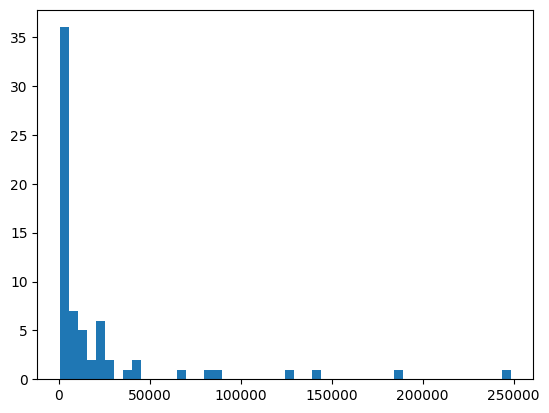

In [55]:
plt.hist(gain_df['Gain'].values, bins=50)

Feature Selection Thresholds

The gain distribution is strongly right-skewed (≈513 to ≈248k; median ≈4.4k, mean ≈22k), indicating that most features contribute little, while a small subset carries most of the predictive signal.

Principle

Thresholds are defined using simple order-of-magnitude heuristics rather than exact statistical cutoffs. This avoids overfitting the threshold design to the observed distribution, while keeping the search space meaningful and stable. Final selection is determined via cross-validation.

Grid
0.0 → baseline (no feature selection)
1,000 → very permissive filtering
5,000 → around median scale
10,000 → moderate filtering
20,000 → around mean scale
40,000 → strong filtering
Rationale

The values span the full observed magnitude range of feature importances and allow the model to evaluate different levels of sparsity. This ensures a balance between data-informed design and robust, unbiased evaluation.

In [84]:
param_grid = {
    "selector__threshold": [
        0.0,                 
        1000,                
        5000,                
        10000,               
        20000,               
        40000               
    ],
    'model__n_estimators': [50, 100, 200],  
    'model__max_depth': [3, 5, 7]
}

In [85]:
grid_search_features = GridSearchCV(
    feature_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid_search_features.fit(X_train_clean, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


KeyboardInterrupt: 